<h1>Gaia Star Cluster Hertzsprung Russel Diagrams (HRD)</h1>

Here are some useful links 
- [European Space Agency Gaia Mission - Writing Queries Turorial](https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries)
- [Gaia's Hertzsprung-Russel Diagram](https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram)
- [Measuring the Age of a Star Cluster](https://www.e-education.psu.edu/astro801/content/l7_p6.html#:~:text=The%20HR%20diagram%20for%20stage,%2D13%20billion%20years%20old)

**In the examples below we will query open clusters in the Milky way and plot it in a Hertzsprung-Russel Diagram (HRD). We will also attempt to identify Zero-order Main Sequence (ZAMS) entry points and Main Sequence Cutoff for these star clusters**

*adapted for the Python for Astronomy Course by Chandru Narayan Nov 1, 2022 using the material develped by Dr. Priya Hasan*


In [1]:
#!echo $PATH  Remove leading '#' for debugging as needed

In [3]:
# Data Folder
data_folder="data_folder"
!ls -l {data_folder}

total 4
-rw-r--r-- 1 jupyter-chandru.narayan.p4-55c04 jupyter-chandru.narayan.p4-55c04 66 Jan 12 03:49 readme.md


In [4]:
#!pip list  # for debugging as needed

In [5]:
#EXECUTE THIS CELL THEN RESTART KERNEL
!pip install astroquery  # for debugging as needed
!pip install scikit-learn # for debugging or as needed

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [6]:
# Create Access to the Gaia Database
from astroquery.gaia import Gaia

# Load Tables from the Gai Database
tables = Gaia.load_tables(only_names=True)

# Print the Table Names in the Gaia Database
for table in tables:
    print(table.name)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
external.apassdr9
external.catwise2020
external.gaiadr2_astrophysical_parameters
external.gaiadr2_geometric_distance
external.gaiaedr3_distance
external.gaiaedr3_gcns_main_1
external.gaiaedr3_gcns_rejected_1
external.gaiaedr3_spurious
external.gaia_eso_survey
external.galex_ais
external.lamost_dr9_lrs
external.lamost_dr9_mrs
external.ravedr5_com
external.ravedr5_dr5
external.ravedr5_gra
external.ravedr5_on
external.ravedr6
external.sdssdr13_photoprimary
external.skymapperdr1_master
external.skymapperdr2_master
external.tmass_xsc
external.xgboost_table1
external.xgboost_table2
gaiadr1.aux_qso_icrf2_match
gaiadr1.ext_phot_zero_point
gaiadr1.allwise_best_neighbour
gaiadr1.allwise_neighbourhood
gaiadr1.gsc23_best_neighbour
gaiadr1.gsc23_neighbourhood
gaiadr1.ppmxl_best_neighbour
gaiadr1.ppmxl_neighbourhood
gaiadr1.sdss_dr9_best_neighbour
gaiadr1

In [7]:
# Get Gaia Sources Table
meta = Gaia.load_table('gaiadr3.gaia_source')
print(meta)

TAP Table name: gaiadr3.gaiadr3.gaia_source
Description: This table has an entry for every Gaia observed source as published with this data release. It contains the basic source parameters, in their final state as processed by the Gaia Data Processing and Analysis Consortium from the raw data coming from the spacecraft. The table is complemented with others containing information specific to certain kinds of objects (e.g.~Solar--system objects, non--single stars, variables etc.) and value--added processing (e.g.~astrophysical parameters etc.). Further array data types (spectra, epoch measurements) are presented separately via Datalink resources.
Num. columns: 152


In [8]:
# Print all columns in the Gaia Source Table
for column in meta.columns:
    print(column.name)

solution_id
designation
source_id
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_frac_odd_win
ruwe
scan_direction_strength_k1
scan_di

## Open Star Cluster M45 in Orion has younger stars
![m45](m45.png)
## Globular Star Cluster M92 in Hercules is VERY OLD!
![m92](m92.png)
## The Gaia Sattelite
Gaia is a space observatory of the European Space Agency, launched in 2013 and expected to operate until 2025. The spacecraft is designed for astrometry: measuring the positions, distances and motions of stars with unprecedented precision.
Gaia  provides astrometry, photometry, and spectroscopy of more than 1000 million stars in the Milky Way. Also data for significant samples of extragalactic and Solar system objects is made available. The Gaia Archive contains deduced positions, parallaxes, proper motions, radial velocities, and brightnesses. Complementary information on multiplicity, photometric variability, and astrophysical parameters is provided for a large fraction of sources.
![gaia](gaia.png)


## Gaia Data

Gaia Data primarily contains of - Right Ascension (RA), Declination (Dec), Parallax, Radial Velocity (RV), Proper Motion in terms of Right Ascension (pmra), and Proper Motion in terms of Declination (pmdec).

1. ✅ **Right Ascension and Declination**- They are the longitude and latitude to position an object in the celestial frame of reference, or they are the celestial coordinates. They are calculated as positions in the plane of the sky. Read more about them at [https://skyandtelescope.org/astronomy-resources/right-ascension-declination-celestial-coordinates/](https://skyandtelescope.org/astronomy-resources/right-ascension-declination-celestial-coordinates/).
[(Image Source)](https://en.wikipedia.org/wiki/Right_ascension)

<img src="https://upload.wikimedia.org/wikipedia/commons/6/66/Ra_and_dec_demo_animation_small.gif" alt="RA Dec" style="width: 50%; float:center;"/> 

2. ✅ **Parallax**- The effect which causes an apparent shift in the position of an object with request to a background when observed from two different points (separated by a distance called basis) It is calculated as the semi-angle of inclination of these two different line of sights from the observation points to the object. Image source and more at: [https://en.wikipedia.org/wiki/Parallax](https://en.wikipedia.org/wiki/Parallax) 

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e3/Stellarparallax2.svg/340px-Stellarparallax2.svg.png" alt="Parallax" style="width: 50%; float:center;"/>

3. ✅ **Radial Velocity**- It is the velocity of an object in a direction away from or towards the Earth (observation point). In a more general sense, it is the velocity between the object and the observation point in the direction of the radius connecting the point and the object

4. ✅ **Proper Motions (RA and Dec)**- Proper Motion is the rate of angular drift in the plane of the sky or in a transverse direction. In other words, pmra and pmdec are the rates of change of the RA and Dec of an object in the sky respectively. Their resultant is also called the transverse velocity or total proper motion. The space velocity of an object is the resultant of the transverse velocity and the radial velocity

### Gaia Data Releases

Gaia data is made publicly available through periodic data releases (DRs). Each Data Release has a richer data than the previous data release as Gaia covers the stars more times and adds new stars and objects as well. We had 3 full releases (DR1, DR2, DR3)  Data Release 3 (DR3) is the latest update. We will be working with the most recent full release, DR2. You can also try working with EDR3 with almost negligible changes to the queries we use here.


### Gaia Archive

Gaia Archive is a remote server which hosts the publicly available Dsta Releases of Gaia in the form of a database. It also provides us an interface to query the data and manipulate it according to our needs on the server itself, without us having the need to download the data first on our local computers. Using the Gaia archive site, we can get data on the positions, brightnesses, distances, and more for millions of stars and do various kinds of science and data visualization from them.

**The Gaia archive can be found here: https://gea.esac.esa.int/archive/**



## Basic Search for Manual Gaia Query and Download
Task: We will use the Basic Search in Gaia Archive to get data of a cluster M45 (Pleiades,  Seven Sisters) in 20 arcminutes radius circle around  it.  We will then read this data in Python and plot the required data.
Steps for Basic Search:

Make sure you're on the Basic query page
In the "Name" field, type in "Messier 45". It should resolve the name. 
To the right, put a "20" and then change the unit from "arc sec" to "arc min". This will tell the archive to search in a radius of 20 arcminutes around M45. There are 60 arcseconds in an arcminute, and 60 arcminutes in a degree. 
Make sure that the "Search In" drop down says "gaiadr3.gaia_source". This specifies the data we want to use is frrom source of Gaia DR3
Click "Submit Query"
You'll see a table pop up with the first 20 results from the query. At the bottom, change "VOTable" to "csv" and click "Download results". This will download a csv to your computer with the queried data in it.

## Review Magnitude and Distance/Parallax Formulas (we drived these in the Star MAgnitudes Module!)
### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
### Note that this quantity appears in the equations below to calculate magnitudes and distance
## 1. How to calculate Magnitudes when distance (in pc) is known
### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
## 2. How to calculate Magnitudes when parallax (in arc-sec) is known
### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
## 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
#### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
## 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

In [9]:
%%html
<div style="text-align:center;">
<iframe src="https://gea.esac.esa.int/archive/" width="900" height="540"></iframe>
</div>

In [10]:
# For use with Manual Search

# Drag and drop the downloaded csv file in to the data_folder and rename to m45.csv

import pandas as pd

target = 'm45'
data_file = f'{target}.csv'
file_path = f'{data_folder}/{data_file}'

# Now we can read the csv file into a pandas dataframe. 
m45 = pd.read_csv(file_path) # data_file to be found in data_folder

# Checking the top few rows of the data and the number of rows and columns
print("(Rows, Columns) =", m45.shape)
m45.head()

(Rows, Columns) = (2000, 36)


,designation,source_id,ra,dec,parallax,pmra,pmdec,ruwe,phot_g_mean_mag,bp_rp,...,ebpminrp_gspphot,target_id,target_ra,target_dec,target_parallax,target_pm_ra,target_pm_dec,target_radial_velocity,epoch,target_separation (deg)
0,Gaia DR3 65225091345088128,65225091345088128,56.599638,24.107784,1.002419,9.238975,-7.678633,1.014527,19.484385,0.947384,...,NaN,messier 45,56.601,24.114,7.364,19.997,-45.548,5.88,2000,0.006159
1,Gaia DR3 65225130001307776,65225130001307776,56.607920,24.115292,NaN,NaN,NaN,NaN,20.633690,1.603994,...,NaN,messier 45,56.601,24.114,7.364,19.997,-45.548,5.88,2000,0.006404
2,Gaia DR3 65225095641479808,65225095641479808,56.603196,24.105173,0.848391,3.162393,-10.339946,0.953647,16.917551,1.638126,...,0.25,messier 45,56.601,24.114,7.364,19.997,-45.548,5.88,2000,0.008835
3,Gaia DR3 65225125704831360,65225125704831360,56.612495,24.111788,0.146353,-0.930217,0.615135,0.945390,19.427362,1.148716,...,NaN,messier 45,56.601,24.114,7.364,19.997,-45.548,5.88,2000,0.010596
4,Gaia DR3 65225198720692736,65225198720692736,56.593645,24.122139,4.983372,10.911748,-20.699802,1.058718,14.331924,1.802323,...,NaN,messier 45,56.601,24.114,7.364,19.997,-45.548,5.88,2000,0.010763


## Let's practice by calculating the Absolute Magnitude of the stars in the M45 csv file we queried earlier and updating the file with it as a new column. We will perform the following steps:
### 1. If M45 csv file does exist, we will read it in for future steps
### 2. If it does not exist, we will perform a simple API query to create the M45 csv file
### 3. Calculate the Absolute Magnitude (see cells above for formula) and add it as a column
### 3. Calculate the Distance using Parallax (see cells above for formula) and add it as a column
### 4. Write out the results as a new csv file
 

In [11]:
# Create Access to the Gaia Database
from astroquery.gaia import Gaia

# Load Tables from the Gaia Database
#tables = Gaia.load_tables(only_names=True)

# Print the Table Names in the Gaia Database
#for table in tables:
#    print(table.name)

# Get Gaia Sources Table
meta = Gaia.load_table('gaiadr3.gaia_source')
#print(meta)

# Print all columns in the Gaia Source Table
for column in meta.columns:
    print(column.name)

solution_id
designation
source_id
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_frac_odd_win
ruwe
scan_direction_strength_k1
scan_di

In [12]:
# Define a Python Query "job" asynchronously within a try-except block
# This will first look for a previously stored file (try-block)
# if it does not exist it will execute the query (except-block)

# designation 	source_id 	ra 	dec 	parallax 	pmra 	pmdec 	phot_g_mean_mag 	bp_rp	has_mcmc_gspphot

import numpy as np
import pandas as pd
from astropy import log

updated_data_file = f'updated_{target}.csv'
updated_file_path = f'{data_folder}/{updated_data_file}'
query_size = 2000

try:
    log.info(f"Getting the DR3 results stored in {updated_file_path}\n")
    #gc = np.recfromcsv(updated_file_path)
    gc = np.genfromtxt(updated_file_path, delimiter=',', names=True, dtype=None)
    desg, sid, ra, dec, plx, pmra, pmdec, amg, bp_rp, dist = \
    gc.designation, gc.source_id, gc.ra, gc.dec, \
    gc.parallax, gc.pmra, gc.pmdec, \
    gc.amg+5*np.log10(gc.parallax)-10, \
    gc.bp_rp, 1000/gc.parallax
    
    print(f"reading results from previously existng {updated_data_file}\n")
    #print(ra, dec, plx, amg, dist)
    df = pd.DataFrame({"desg": desg, "ra": ra, "dec": dec, "plx": plx, "pmra": pmra, "pmdec": pmdec, "amg": amg, "bp_rp": bp_rp, "dist": dist})
    print(df)
    

except OSError:
    query = (" SELECT"
            " TOP {}".format(query_size)+
            " designation, source_id, ra, dec, parallax, pmra, pmdec,  bp_rp, "
            "phot_g_mean_mag+5*log10(parallax)-10 as amg, 1000/parallax as dist"
            " FROM gaiadr3.gaia_source"
            " WHERE parallax > 0"
            " AND bp_rp > -0.75"
            " AND bp_rp < 2")
    
    job = Gaia.launch_job_async(query, dump_to_file=True, output_format="csv",
                                 output_file=updated_file_path)
    job
    print(job)


INFO: Getting the DR3 results stored in data_folder/updated_m45.csv
 [unknown]
Jobid: 1736829450932O
Phase: COMPLETED
Owner: None
Output file: data_folder/updated_m45.csv
Results: None


## Now that we have practiced we will setup another cone search using Gaia
## We will then use the Proper Motion  in RA and DEC to filter foreground stars
### We will then Plot all of the stars in a Hertzsprung Russell Diagram Abs Mag vs Temp (Color)

## Setup for API Gaia Target Cone Search and Download

In [13]:
# Parameters for API Query & HRD (20 minutes radius around M45 center) - Change for each query!
target = "M45" # target to query
object_radius = 20 # in arc minutes
object_radius_deg = object_radius/60
num_stars = 5000 #maximum number of stars to retrieve

In [14]:
import numpy as np
import pandas as pd
import math
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

In [15]:
# import astroquery and astropy packages
import astropy.units as u
import astropy.coordinates as coord
from astroquery.gaia import Gaia
from astroquery.vizier import Vizier


In [16]:
## making a GAIA cone_search

coordinate = coord.SkyCoord.from_name(target)
print(coordinate)
radius = u.Quantity(1, u.deg) * object_radius_deg
print(radius)
Gaia.ROW_LIMIT = -1
#j = Gaia.cone_search_async(coordinate, *, radius, table_name="gaiaedr3.gaia_source")
j = Gaia.cone_search_async(coordinate, radius=radius, table_name="gaiaedr3.gaia_source")
r = j.get_results()
print(type(r))
print(r)

<SkyCoord (ICRS): (ra, dec) in deg
    (56.601, 24.114)>
0.3333333333333333 deg
INFO: Query finished. [astroquery.utils.tap.core]
<class 'astropy.table.table.Table'>
    solution_id             designation         ...         dist        
                                                ...                     
------------------- --------------------------- ... --------------------
1636042515805110273 Gaia EDR3 65225091345088128 ... 0.006337645533631022
1636042515805110273 Gaia EDR3 65225130001307776 ... 0.006440119370323977
1636042515805110273 Gaia EDR3 65225095641479808 ... 0.009046829012056418
1636042515805110273 Gaia EDR3 65225198720692736 ... 0.010557677227241321
1636042515805110273 Gaia EDR3 65225125704831360 ... 0.010714308627453529
1636042515805110273 Gaia EDR3 65225095639539072 ... 0.011339815155759101
1636042515805110273 Gaia EDR3 65225198718747520 ... 0.011823201315482694
1636042515805110273 Gaia EDR3 65225164360956288 ... 0.014526864315680931
1636042515805110273 Gaia EDR3 6

In [17]:
## save the ASCII table as a pandas dataframe
all_stars = r.to_pandas()
all_stars
type(all_stars)

pandas.core.frame.DataFrame

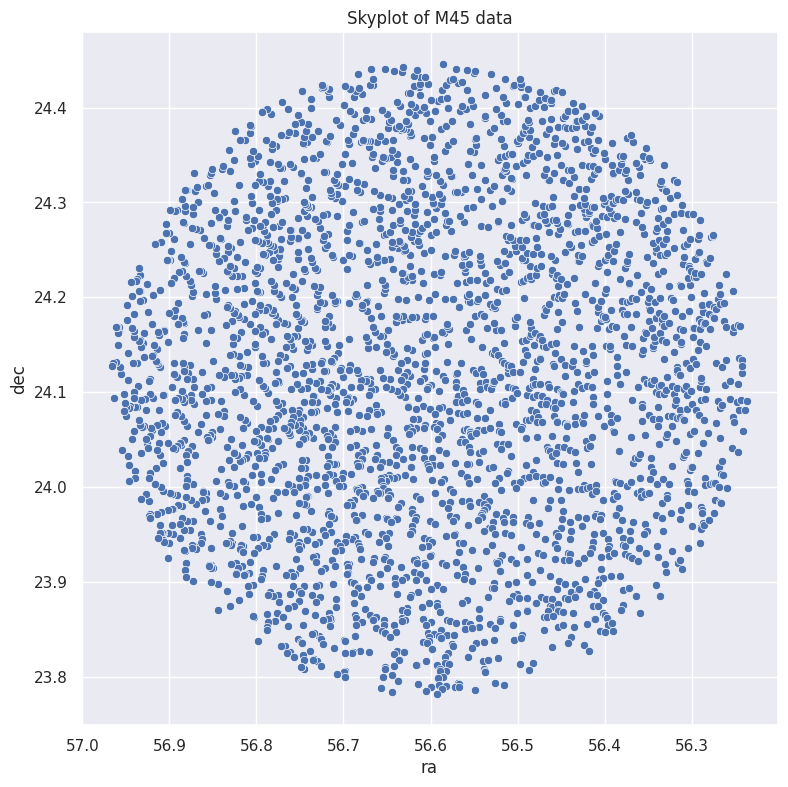

In [18]:
## plotting the skyplot 

#fig, axs = plt.subplots(1)
#plt.margins(0.005, tight=True)
#axs.set_aspect('equal')
sns.set(rc={'figure.figsize':(9,9)})
skyplot = sns.scatterplot(x='ra', y='dec', data = all_stars)
#skyplot = sns.scatterplot(x='ra', y='dec', data = members)
skyplot.invert_xaxis()
plt.title('Skyplot of ' + target + ' data')
plt.show()

/tmp/ipykernel_1311/533507744.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='phot_g_mean_mag',palette='RdYlGn',


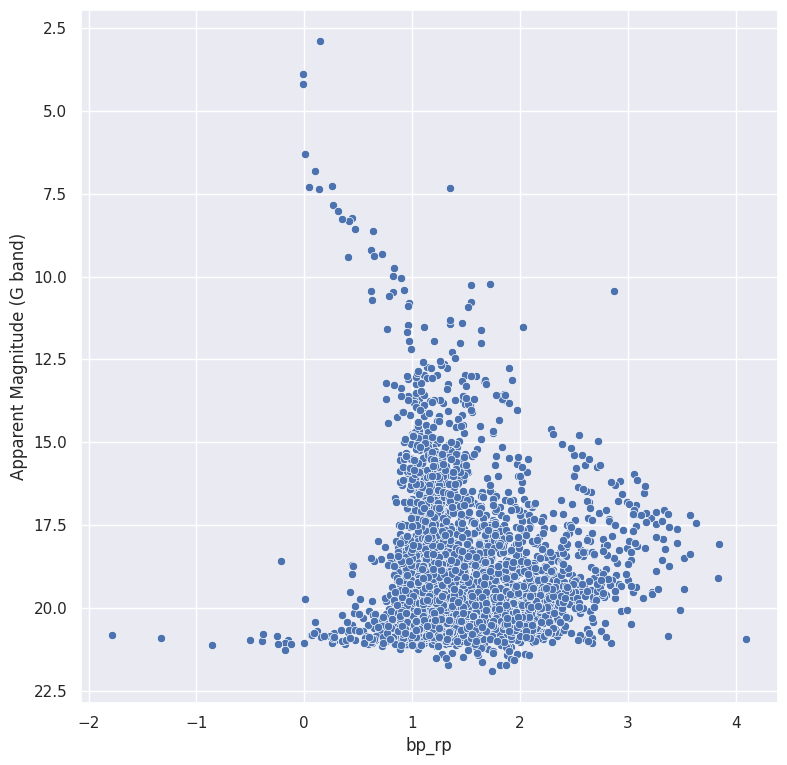

In [20]:
sns.scatterplot(x = 'bp_rp', y='phot_g_mean_mag',palette='RdYlGn',
                data = all_stars)
plt.ylabel('Apparent Magnitude (G band)')
#plt.xlim(0,3)
#sns.scatterplot(hr.b_v+0.5, hr.V+10)

plt.gca().invert_yaxis()

<Axes: xlabel='pmra', ylabel='pmdec'>

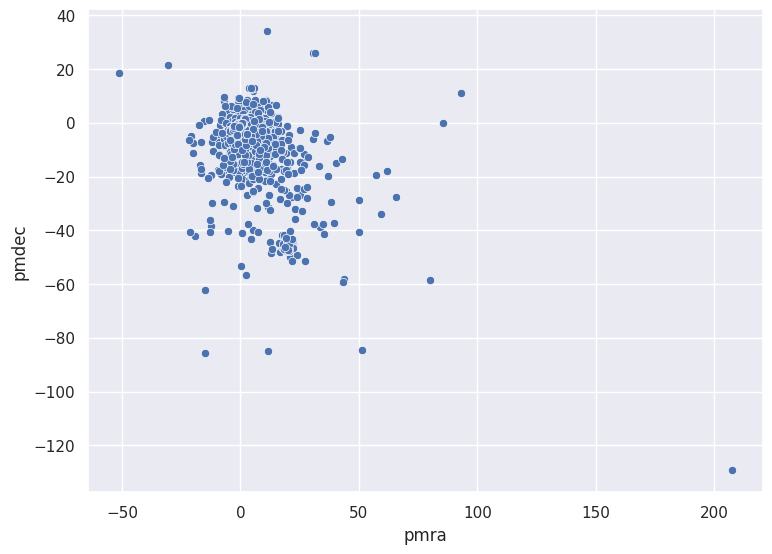

In [21]:
import seaborn as sns
sns.set(rc={'figure.figsize':(8.7,6.27)})

#sns.scatterplot(x='pmra', y='pmdec', data=features[features.labels > -1], hue='labels',legend='full')

sns.scatterplot(x='pmra', y='pmdec', data=all_stars)

<Axes: xlabel='pmra', ylabel='pmdec'>

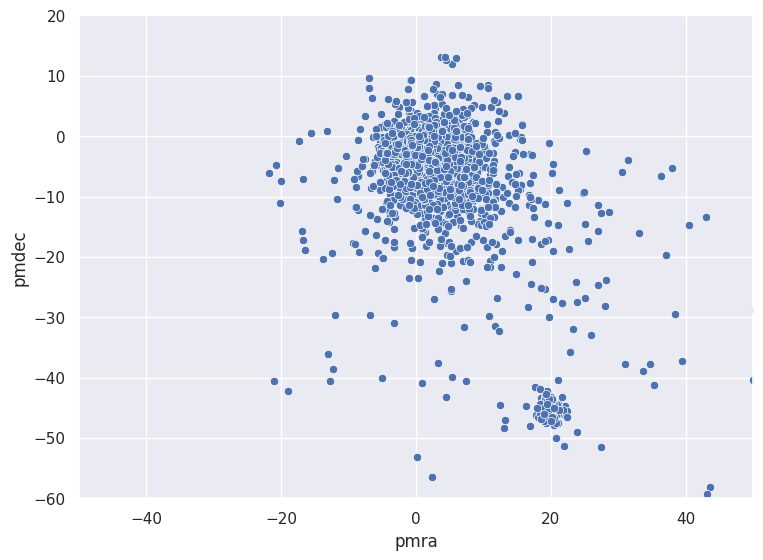

In [22]:
# limit ranges to zoom in
plt.xlim(-50,50)
plt.ylim(-60,20)
sns.scatterplot(x='pmra', y='pmdec', data=all_stars)

(-20.0, 30.0)

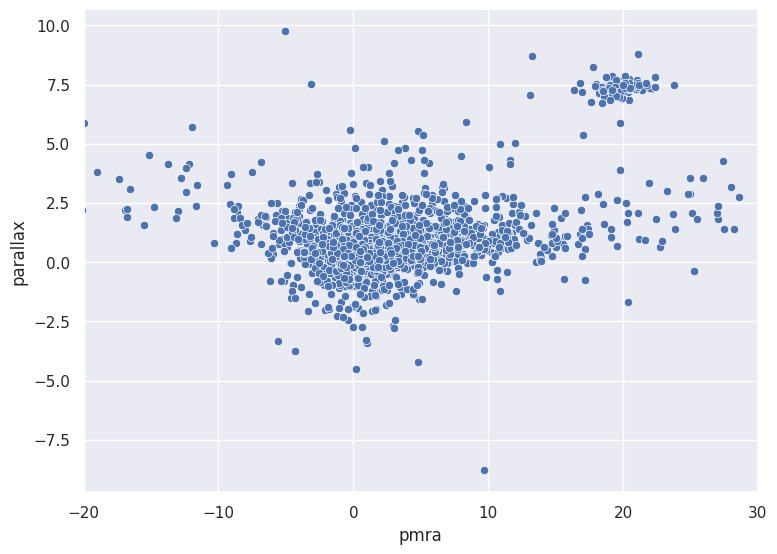

In [23]:
sns.scatterplot(x='pmra', y='parallax', data=all_stars)
plt.xlim([-20, 30])

(-50.0, -40.0)

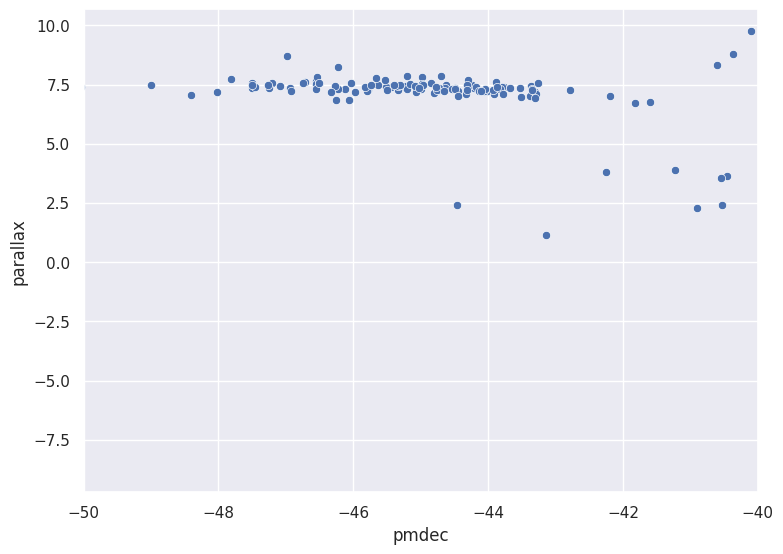

In [25]:
sns.scatterplot(x='pmdec', y='parallax', data=all_stars)
plt.xlim([-50,-40])

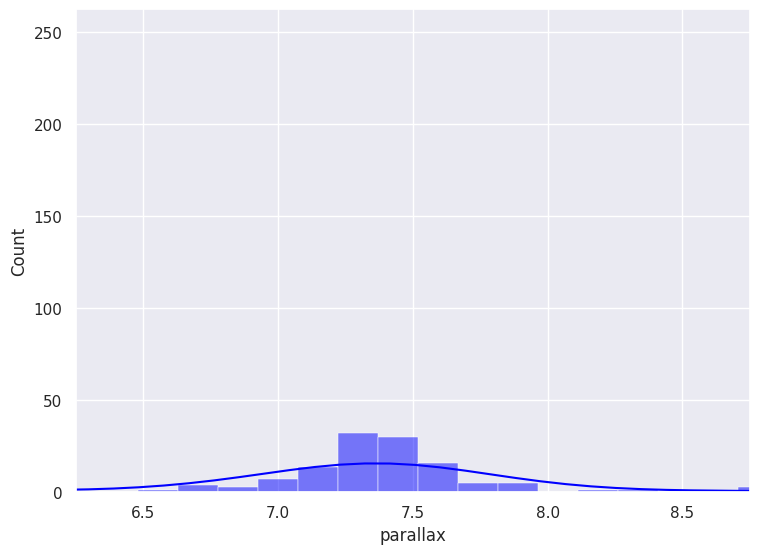

In [26]:
sns.histplot(x='parallax', data=all_stars,
              kde=True,color='blue')
#sns.histplot(x='parallax', data=rf_member, label='RF Member',
 #            kde=True,color='Green')
#plt.legend()
plt.xlim([6.25,8.75])
plt.show()

/tmp/ipykernel_1311/50661191.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


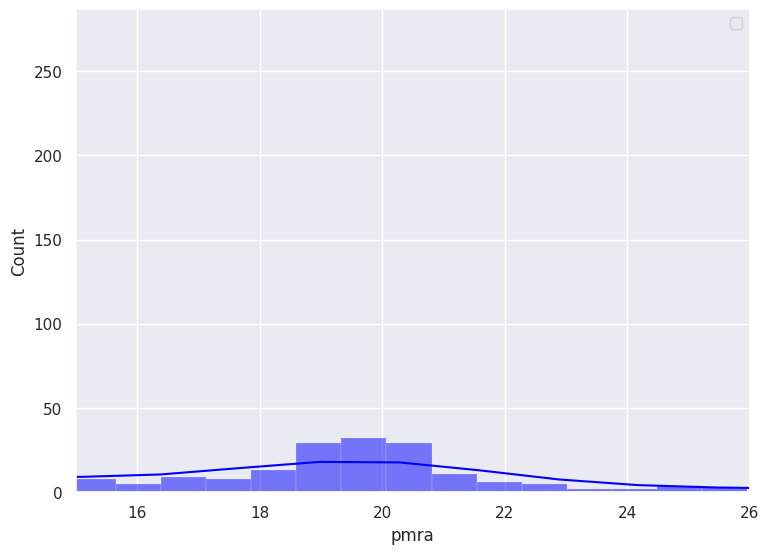

In [27]:
sns.histplot(x='pmra', data=all_stars,
              kde=True,color='blue')
#sns.histplot(x='parallax', data=rf_member, label='RF Member',
 #            kde=True,color='Green')
plt.legend()
plt.xlim([15,26])
plt.show()

/tmp/ipykernel_1311/1214694829.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


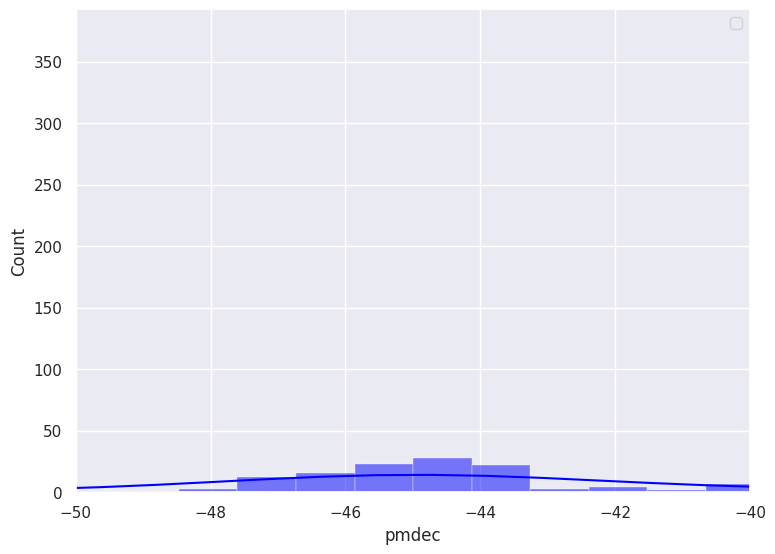

In [28]:
sns.histplot(x='pmdec', data=all_stars,
              kde=True,color='blue')
#sns.histplot(x='parallax', data=rf_member, label='RF Member',
 #            kde=True,color='Green')
plt.xlim([-50,-40])
plt.legend()
plt.show()

In [29]:
all_stars.describe()

,solution_id,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,...,dr2_radial_velocity_error,dr2_rv_nb_transits,dr2_rv_template_teff,dr2_rv_template_logg,dr2_rv_template_fe_h,l,b,ecl_lon,ecl_lat,dist
count,2.927000e+03,2.927000e+03,2.927000e+03,2927.0,2927.000000,2927.000000,2927.000000,2927.000000,2553.000000,2553.000000,...,71.000000,2927.000000,71.000000,71.000000,71.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000
mean,1.636043e+18,6.563266e+16,9.239564e+08,2016.0,56.605572,1.136737,24.122601,0.810932,1.006198,0.448121,...,3.336374,0.175265,5190.140625,3.598592,-0.169014,166.459764,-23.605199,59.759131,4.121103,0.218650
std,0.000000e+00,6.642450e+14,5.245968e+08,0.0,0.182177,3.480476,0.162365,2.423839,1.775541,0.448333,...,3.452522,1.148729,730.049866,0.607217,0.477670,0.183732,0.160199,0.164848,0.164235,0.079226
min,1.636043e+18,6.519193e+16,5.396600e+04,2016.0,56.236885,0.012181,23.781850,0.008992,-8.791216,0.014245,...,0.163520,0.000000,4000.000000,3.000000,-1.500000,166.099471,-23.946664,59.419706,3.782317,0.006338
25%,1.636043e+18,6.521550e+16,4.633514e+08,2016.0,56.456765,0.118823,23.995399,0.085056,0.180700,0.114601,...,0.778168,0.000000,4500.000000,3.000000,0.000000,166.309044,-23.728987,59.629789,3.991244,0.159612
50%,1.636043e+18,6.523080e+16,9.367930e+08,2016.0,56.610093,0.330569,24.119591,0.235462,0.577512,0.287605,...,2.137708,0.000000,5500.000000,3.500000,0.000000,166.463266,-23.602026,59.764184,4.119892,0.231972
75%,1.636043e+18,6.671133e+16,1.398246e+09,2016.0,56.750508,0.829884,24.254645,0.582078,1.197278,0.632647,...,4.055761,0.000000,5500.000000,4.500000,0.000000,166.608403,-23.478181,59.892738,4.252150,0.284190
max,1.636043e+18,6.678503e+16,1.811695e+09,2016.0,56.965469,86.781815,24.446309,53.509377,9.743848,3.483384,...,12.802958,12.000000,6500.000000,4.500000,0.000000,166.823023,-23.283973,60.086417,4.442835,0.333257


In [30]:
all_stars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2927 entries, 0 to 2926
Data columns (total 100 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   solution_id                      2927 non-null   int64  
 1   designation                      2927 non-null   object 
 2   source_id                        2927 non-null   int64  
 3   random_index                     2927 non-null   int64  
 4   ref_epoch                        2927 non-null   float64
 5   ra                               2927 non-null   float64
 6   ra_error                         2927 non-null   float32
 7   dec                              2927 non-null   float64
 8   dec_error                        2927 non-null   float32
 9   parallax                         2553 non-null   float64
 10  parallax_error                   2553 non-null   float32
 11  parallax_over_error              2553 non-null   float32
 12  pm                 

In [31]:
mask = (all_stars.parallax >= 6.25) & (all_stars.parallax <= 8.75) &(all_stars.pmra < 26) & (all_stars.pmra > 15)& (all_stars.pmdec > -50) & (all_stars.pmdec < -40)


In [46]:
abs_mag = all_stars['phot_g_mean_mag'] + 5 * np.log10(all_stars['parallax']) - 10
print(abs_mag)

0        9.486046
1             NaN
2        6.560531
3        7.819540
4        5.254368
          ...    
2922    10.024963
2923          NaN
2924     0.313939
2925          NaN
2926          NaN
Length: 2927, dtype: float64


/opt/tljh/user/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [48]:
all_stars['abs_mag']=abs_mag

In [58]:
members = all_stars[mask]

In [59]:
members.describe()
members.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107 entries, 17 to 2896
Columns: 101 entries, solution_id to abs_mag
dtypes: Int16(4), bool(2), float32(59), float64(15), int16(17), int64(3), object(1)
memory usage: 46.4+ KB


In [60]:
print(members)

              solution_id                  designation          source_id  \
17    1636042515805110273  Gaia EDR3 65226401312036864  65226401312036864   
22    1636042515805110273  Gaia EDR3 65224889481112832  65224889481112832   
63    1636042515805110273  Gaia EDR3 65229734206151680  65229734206151680   
97    1636042515805110273  Gaia EDR3 65225611037551360  65225611037551360   
155   1636042515805110273  Gaia EDR3 65224442806459008  65224442806459008   
...                   ...                          ...                ...   
2816  1636042515805110273  Gaia EDR3 65208396808627840  65208396808627840   
2877  1636042515805110273  Gaia EDR3 65199978672758272  65199978672758272   
2880  1636042515805110273  Gaia EDR3 65275501377570944  65275501377570944   
2887  1636042515805110273  Gaia EDR3 66734514652754688  66734514652754688   
2896  1636042515805110273  Gaia EDR3 65284228751087872  65284228751087872   

      random_index  ref_epoch         ra  ra_error        dec  dec_error  \

In [61]:
#members_clean = members.dropna()
#print(members_clean)

/tmp/ipykernel_1311/3691812159.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
/tmp/ipykernel_1311/3691812159.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',


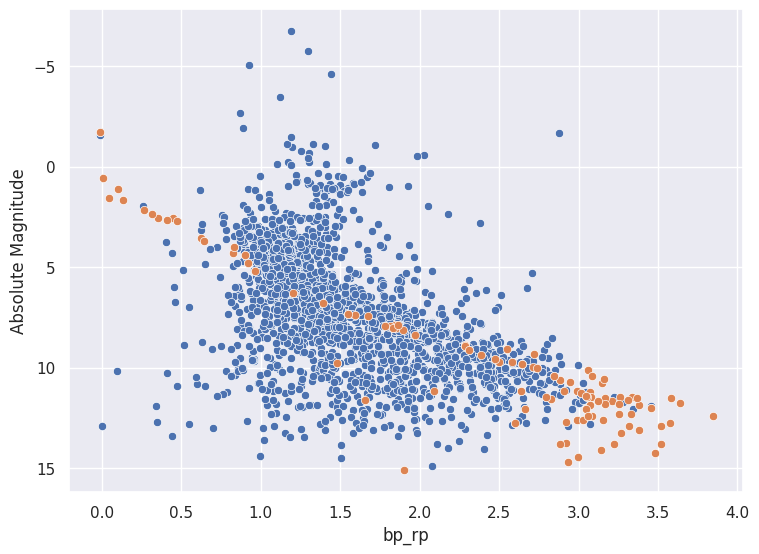

In [63]:

sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
                data = all_stars)
sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
                data = members)
plt.ylabel('Absolute Magnitude')
#plt.xlim(0,3)
#sns.scatterplot(hr.b_v+0.5, hr.V+10)

plt.gca().invert_yaxis()

/tmp/ipykernel_1311/2972709378.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',


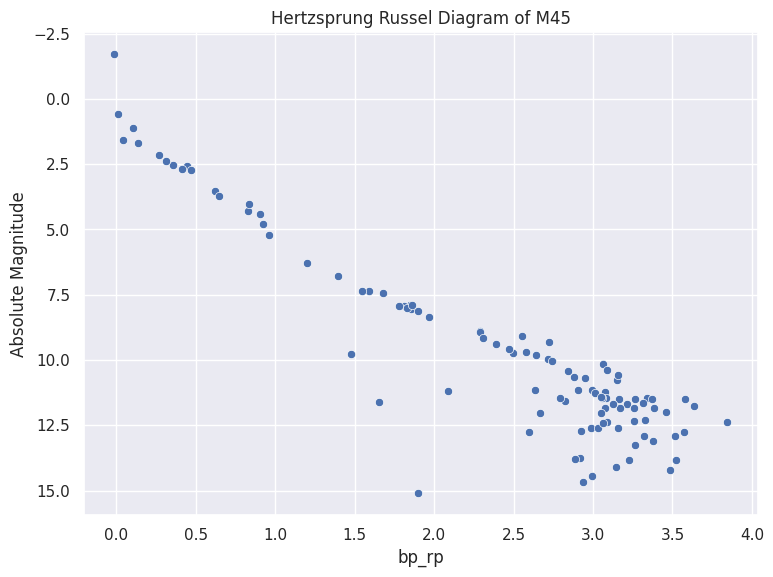

In [64]:
sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
                data = members)
plt.ylabel('Absolute Magnitude')
#plt.xlim(0,3)
#sns.scatterplot(hr.b_v+0.5, hr.V+10)
plt.gca().invert_yaxis()
plt.title('Hertzsprung Russel Diagram of ' + target)
out_file="{}/{}_HRD.png".format(data_folder,target)
plt.savefig(out_file)

/tmp/ipykernel_1311/2972709378.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',


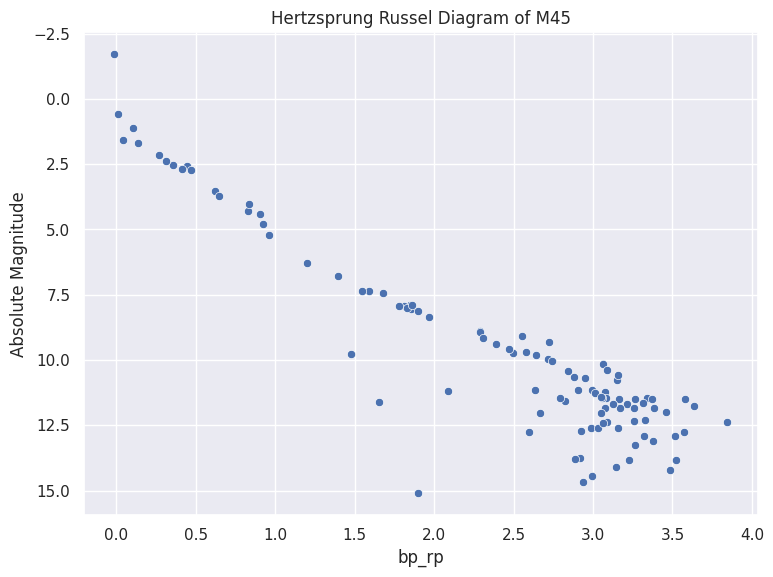

In [56]:
sns.scatterplot(x = 'bp_rp', y='abs_mag',palette='RdYlGn',
                data = members)
plt.ylabel('Absolute Magnitude')
#plt.xlim(0,3)
#sns.scatterplot(hr.b_v+0.5, hr.V+10)
plt.gca().invert_yaxis()
plt.title('Hertzsprung Russel Diagram of ' + target)
out_file="{}/{}_HRD.png".format(data_folder,target)
plt.savefig(out_file)

/tmp/ipykernel_1311/1014058383.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  members['abs_mag']=abs_mag


#### Your Assignment: Plot HRD for a few other clusters M67, M44, NGC1893, NGC581, M92, M13) to see the similarities and differences in HRDs.
